In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from pathlib import Path  # import Path from pathlib module

(256, 256, 3)


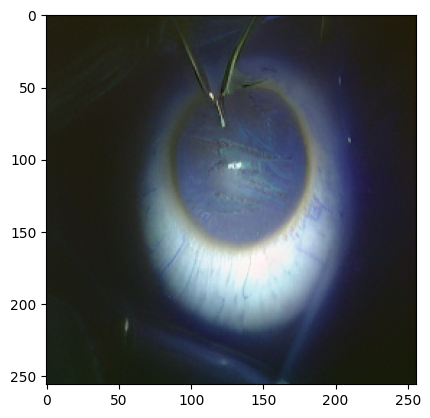

<class 'numpy.ndarray'>
(256, 256)
[0 1 2 7 8]


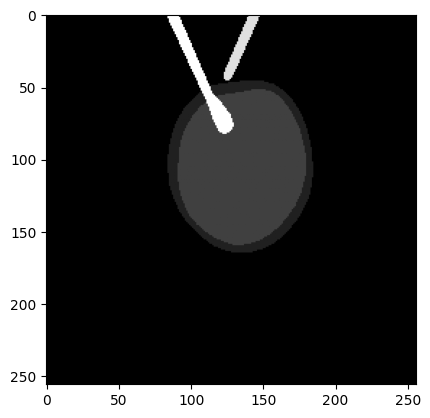

In [58]:

# case = "5017"
# file_num = "20"

main_path = Path("/home/MichalMo/projects/ControlNet-diffusers/results/eval_manual")

img_file = "/home/MichalMo/projects/ControlNet-diffusers/results/eval_manual/sample_000.png"

image = cv2.imread(img_file)  # Load as grayscale
print(image.shape)

plt.imshow(image, cmap="gray")
plt.show()





mask_file = "/home/MichalMo/projects/ControlNet-diffusers/results/eval_manual/sample_000_cond.png"

# mask_file = "/home/MichalMo/projects/SurGrID/datasets/Cataract-1K/Segmentation_dataset/Annotations/Images-and-Supervisely-Annotations/case_5013/mask_anatomy_inst/case5013_33.png"

mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)  # Load as grayscale

print(type(mask))
# mask = np.array(mask)
print(mask.shape)
print(np.unique(mask))


plt.imshow(mask, cmap="gray")




In [2]:

def grayscale_to_color_mask(seg_image, dataset):
    """
    Convert grayscale-like segmentation image [H, W, 3] with values 0–13
    into a color RGB visualization [H, W, 3].

    Args:
        seg_image (np.ndarray): Input segmentation image, shape (H, W, 3), dtype uint8,
                                values in range [0, 13].
    Returns:
        np.ndarray: RGB color image of shape (H, W, 3), dtype uint8.
    """
    # assert seg_image.ndim == 3 and seg_image.shape[2] == 3, \
    #     f"Expected [H,W,3], got {seg_image.shape}"

    # Convert to single-channel class map
    class_map = seg_image.astype(np.uint8)  # values 0–13

    # Define a color palette (you can customize)
    if dataset =="cataract":
        color_palette = np.array([
            [  0,   0,   0],   # 0: background
            [128,   0,   0],   # 1
            [  0, 128,   0],   # 2
            [128, 128,   0],   # 3
            [  0,   0, 128],   # 4
            [128,   0, 128],   # 5
            [  0, 128, 128],   # 6
            [128, 128, 128],   # 7
            [ 64,   0,   0],   # 8
            [192,   0,   0],   # 9
            [ 64, 128,   0],   # 10
            [192, 128,   0],   # 11
            [ 64,   0, 128],   # 12
            [192,   0, 128],   # 13
        ], dtype=np.uint8)

    elif dataset =="cadis":
        color_palette = np.array([
        [  0,   0,   0],   # 0  background
        [128,   0,   0],   # 1
        [  0, 128,   0],   # 2
        [128, 128,   0],   # 3
        [  0,   0, 128],   # 4
        [128,   0, 128],   # 5
        [  0, 128, 128],   # 6
        [128, 128, 128],   # 7
        [ 64,   0,   0],   # 8
        [192,   0,   0],   # 9
        [ 64, 128,   0],   # 10
        [192, 128,   0],   # 11
        [ 64,   0, 128],   # 12
        [192,   0, 128],   # 13
        [ 64, 128, 128],   # 14
        [192, 128, 128],   # 15
        [  0,  64,   0],   # 16
        [128,  64,   0],   # 17
        [  0, 192,   0],   # 18
        [128, 192,   0],   # 19
        [  0,  64, 128],   # 20
        [128,  64, 128],   # 21
        [  0, 192, 128],   # 22
        [128, 192, 128],   # 23
        [ 64,  64,   0],   # 24
        [192,  64,   0],   # 25
        [ 64, 192,   0],   # 26
        [192, 192,   0],   # 27
        [ 64,  64, 128],   # 28
        [192,  64, 128],   # 29
        [ 64, 192, 128],   # 30
        [192, 192, 128],   # 31
        [  0,  64, 192],   # 32
        [128,  64, 192],   # 33
        [  0, 192, 192],   # 34
        [255, 255, 255],   # 35  (white / special)
    ], dtype=np.uint8)

    # Map class indices to colors
    rgb_mask = color_palette[class_map]  # shape [H, W, 3]

    return rgb_mask






def overlay_segmentation(image, rgb_mask, alpha=0.5):
    """
    Overlay a color segmentation mask on top of an image with transparency.

    Args:
        image (np.ndarray): Original image, shape (H, W, 3), dtype uint8, range [0,255].
        rgb_mask (np.ndarray): Segmentation mask in RGB colors, same shape and dtype.
        alpha (float): Transparency for the mask. 0 = only image, 1 = only mask.

    Returns:
        np.ndarray: Blended RGB image, dtype uint8, shape (H, W, 3).
    """
    assert image.shape == rgb_mask.shape, f"Shape mismatch: {image.shape} vs {rgb_mask.shape}"
    assert 0.0 <= alpha <= 1.0, "alpha must be between 0 and 1"

    # Convert to float for blending
    image_f = image.astype(np.float32)
    mask_f = rgb_mask.astype(np.float32)

    # Blend: weighted average
    blended = (1 - alpha) * image_f + alpha * mask_f

    # Clip and convert back to uint8
    blended = np.clip(blended, 0, 255).astype(np.uint8)
    return blended

In [14]:

eval_path = "eval_manual_cataract_fold0_3_cont1_114543_i30"
main_path = Path(f"/home/MichalMo/projects/ControlNet-diffusers/results/{eval_path}")



# f = open(os.path.join(main_path, "org_image_paths.txt"))
# image_paths = f.readlines()
# print(image_paths)

images_names = os.listdir(main_path)

x_n = set([x.split("_")[1] for x in images_names])

for i in x_n:
    print(i)

    # print(org_image_path[:-2])
    org_image_path = f"/home/MichalMo/projects/ControlNet-diffusers/results/{eval_path}/sample_{i:03}_org.png"

    org_image = cv2.imread(org_image_path)  # Load as grayscale


    org_image = cv2.cvtColor(org_image, cv2.COLOR_BGR2RGB)
    # print(org_image.shape, org_image.dtype, np.min(org_image), np.max(image))

    org_image = Image.fromarray(org_image)  


    plt.figure(figsize=(16,4))
    plt.subplot(141)
    plt.imshow(org_image, cmap="gray")

    # plt.show()


    ##########################################################

    # plt.imshow(overlay)
    img_file = f"/home/MichalMo/projects/ControlNet-diffusers/results/{eval_path}/sample_{i:03}.png"

    image = cv2.imread(img_file)  
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_pil = Image.fromarray(image)  

    # print(image.shape, image.dtype, np.max(image))




    mask_file = f"/home/MichalMo/projects/ControlNet-diffusers/results/{eval_path}/sample_{i:03}_cond.png"

    # mask_file = "/home/MichalMo/projects/SurGrID/datasets/Cataract-1K/Segmentation_dataset/Annotations/Images-and-Supervisely-Annotations/case_5013/mask_anatomy_inst/case5013_33.png"

    mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)  # Load as grayscale


    plt.subplot(142)

    plt.imshow(mask, cmap="gray")

#     plt.show()


    print(mask.shape, mask.dtype, np.max(mask), np.unique(mask))



    rgb_mask = grayscale_to_color_mask(mask, dataset ="cataract")
    print(rgb_mask.shape, rgb_mask.dtype)

    plt.subplot(143)

    overlay = overlay_segmentation(image, rgb_mask, alpha=0.4)

    plt.imshow(image_pil)




    plt.subplot(144)



    plt.imshow(overlay, cmap="gray")



    plt.show()
    # new_im.save(case_folder + '/' + folder_overlay+ '/' +out_name)  

344


[ WARN:0@1931.084] global loadsave.cpp:275 findDecoder imread_('/home/MichalMo/projects/ControlNet-diffusers/results/eval_manual_cataract_fold0_3_cont1_114543_i30/sample_344_org.png'): can't open/read file: check file path/integrity


error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [7]:
images_names = os.listdir(main_path)
len(images_names)

1227

In [12]:
x_n = set([x.split("_")[1] for x in images_names])
len(x_n)

409

In [13]:
x_n

{'000',
 '001',
 '002',
 '003',
 '004',
 '005',
 '006',
 '007',
 '008',
 '009',
 '010',
 '011',
 '012',
 '013',
 '014',
 '015',
 '016',
 '017',
 '018',
 '019',
 '020',
 '021',
 '022',
 '023',
 '024',
 '025',
 '026',
 '027',
 '028',
 '029',
 '030',
 '031',
 '032',
 '033',
 '034',
 '035',
 '036',
 '037',
 '038',
 '039',
 '040',
 '041',
 '042',
 '043',
 '044',
 '045',
 '046',
 '047',
 '048',
 '049',
 '050',
 '051',
 '052',
 '053',
 '054',
 '055',
 '056',
 '057',
 '058',
 '059',
 '060',
 '061',
 '062',
 '063',
 '064',
 '065',
 '066',
 '067',
 '068',
 '069',
 '070',
 '071',
 '072',
 '073',
 '074',
 '075',
 '076',
 '077',
 '078',
 '079',
 '080',
 '081',
 '082',
 '083',
 '084',
 '085',
 '086',
 '087',
 '088',
 '089',
 '090',
 '091',
 '092',
 '093',
 '094',
 '095',
 '096',
 '097',
 '098',
 '099',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '120',
 '121',
 '122',
 '123',
 '124',


In [29]:
x_c = 0

for x in images_names:
    # print(x)
    if "org" in x or "cond" in x:
        # print(x)
        print(x.split("_")[4])
    else:
        print(x)
        print(x.split("_")[3])

# [x.split("_")[3] for x in images_names]
x_c

5017
5015
sample_342_case_5334_case5334_12.png
5334
5014
sample_103_case_5015_case5015_24.png
5015
sample_053_case_5014_case5014_54.png
5014
5015
5014
5014
5303
5303
5303
5334
sample_355_case_5334_case5334_26.png
5334
5014
5014
sample_171_case_5017_case5017_24.png
5017
sample_220_case_5051_case5051_04.png
5051
sample_299_case_5303_case5303_24.png
5303
5015
5014
5017
sample_114_case_5015_case5015_35.png
5015
5017
5014
5015
sample_348_case_5334_case5334_18.png
5334
5334
sample_110_case_5015_case5015_31.png
5015
5017
sample_139_case_5015_case5015_60.png
5015
5303
sample_022_case_5014_case5014_23.png
5014
sample_095_case_5015_case5015_16.png
5015
sample_035_case_5014_case5014_36.png
5014
5051
5051
5017
5303
5303
sample_214_case_5017_case5017_67.png
5017
sample_201_case_5017_case5017_54.png
5017
5014
5015
5334
5017
sample_293_case_5303_case5303_18.png
5303
5017
5017
5015
5014
sample_186_case_5017_case5017_39.png
5017
5014
5014
sample_175_case_5017_case5017_28.png
5017
sample_041_case_5014_c

0